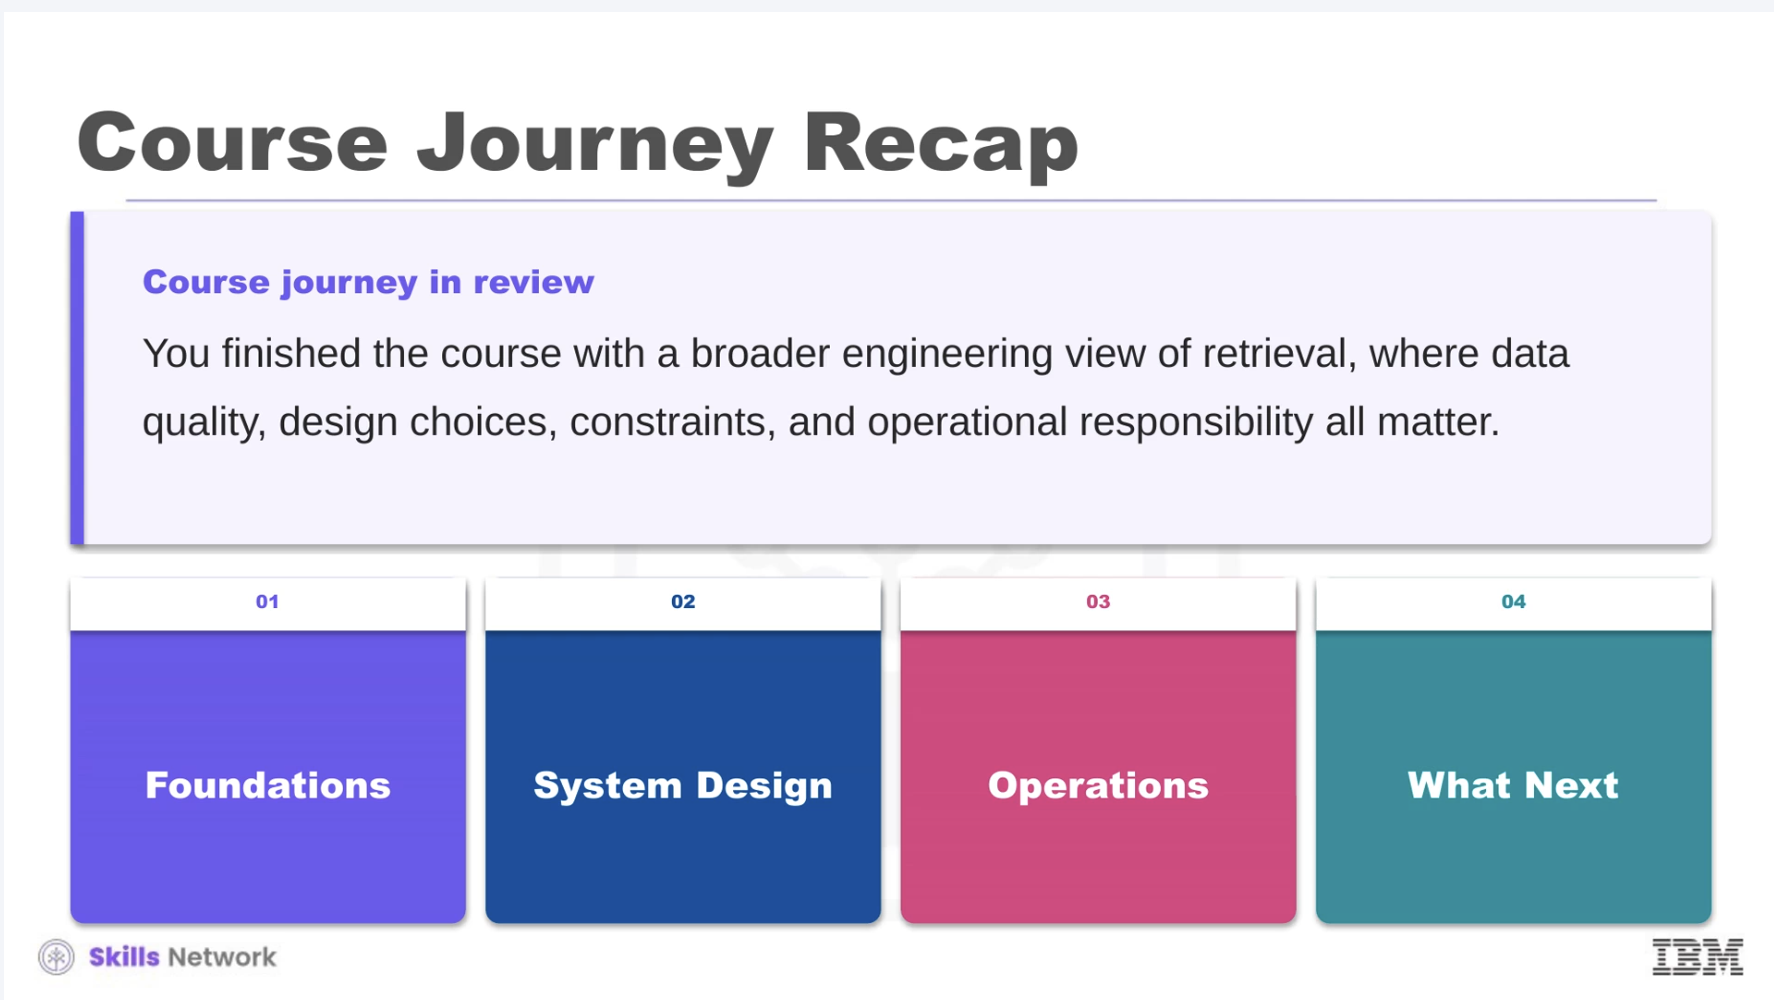
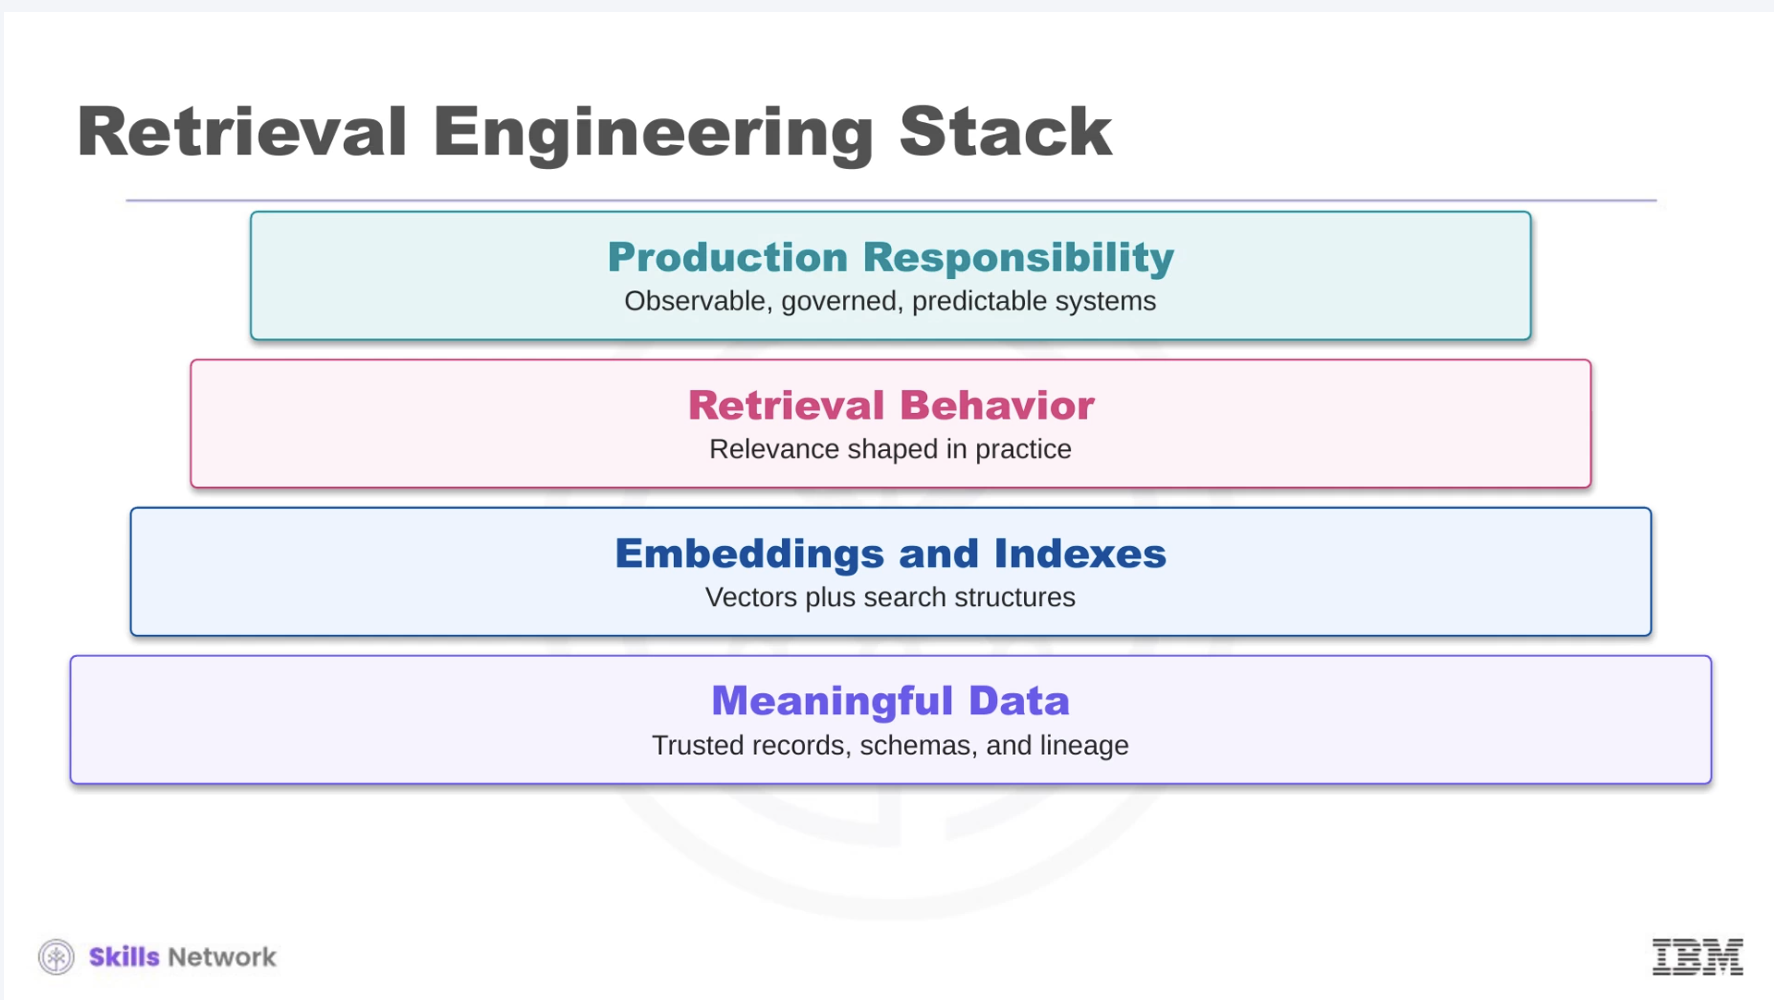
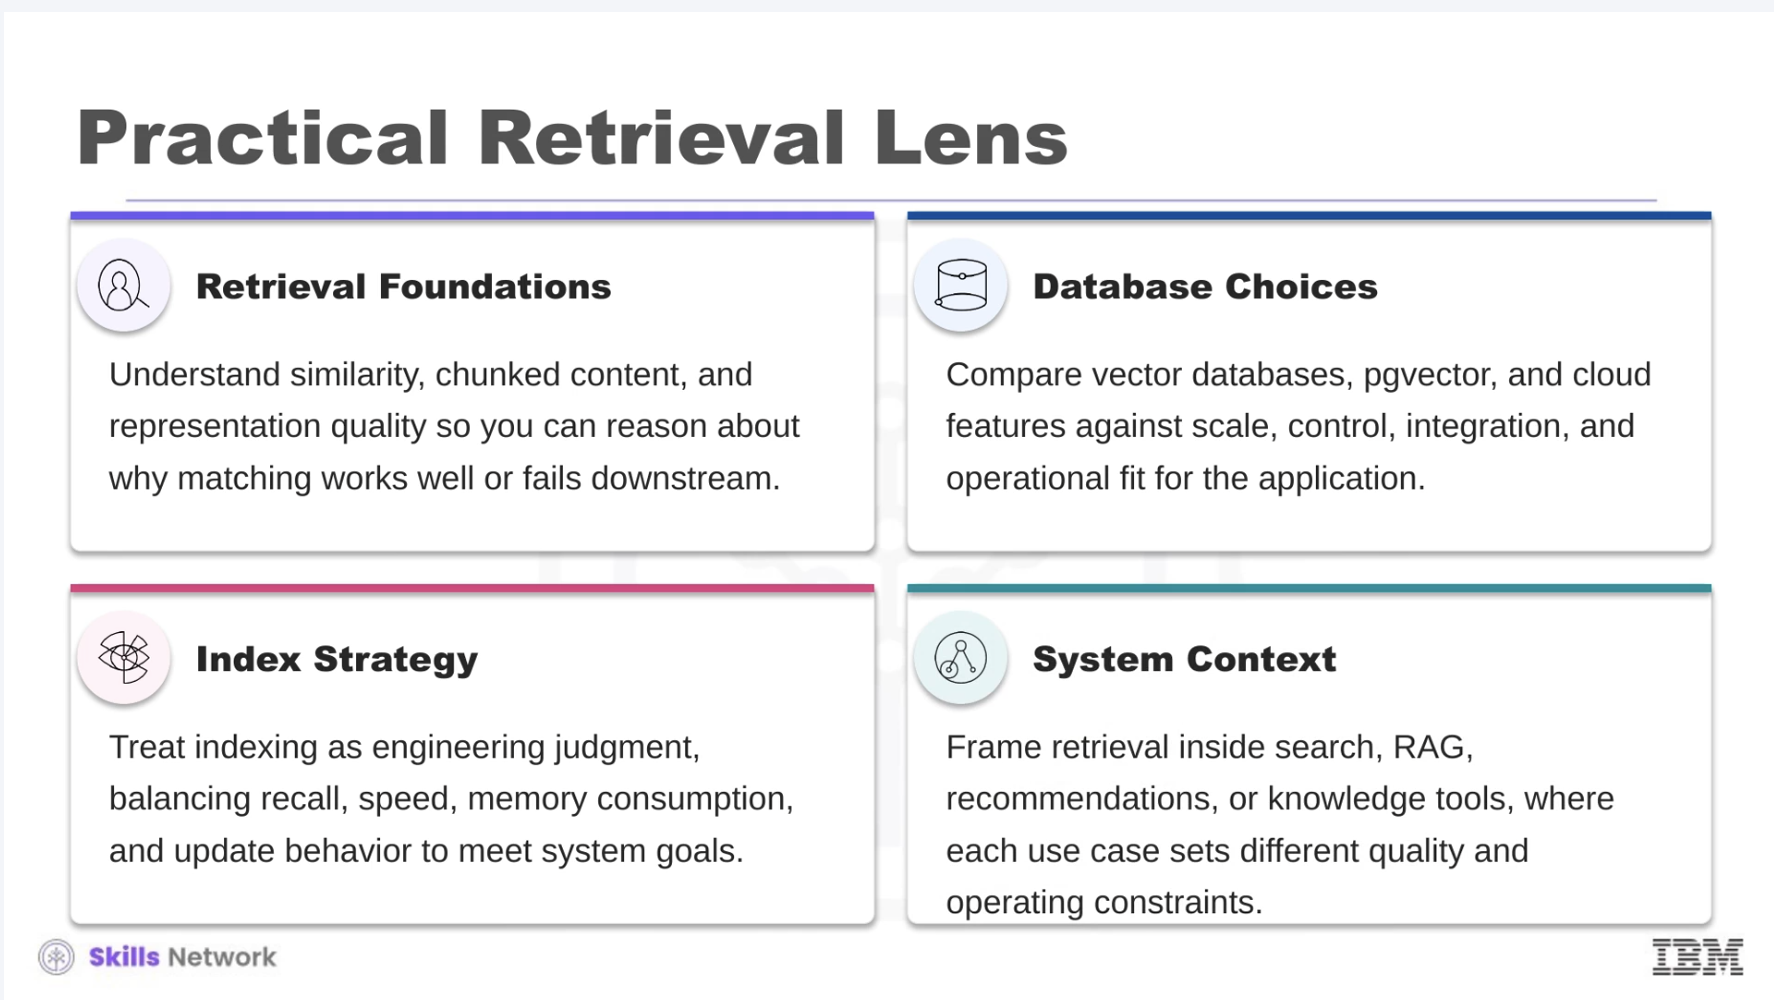
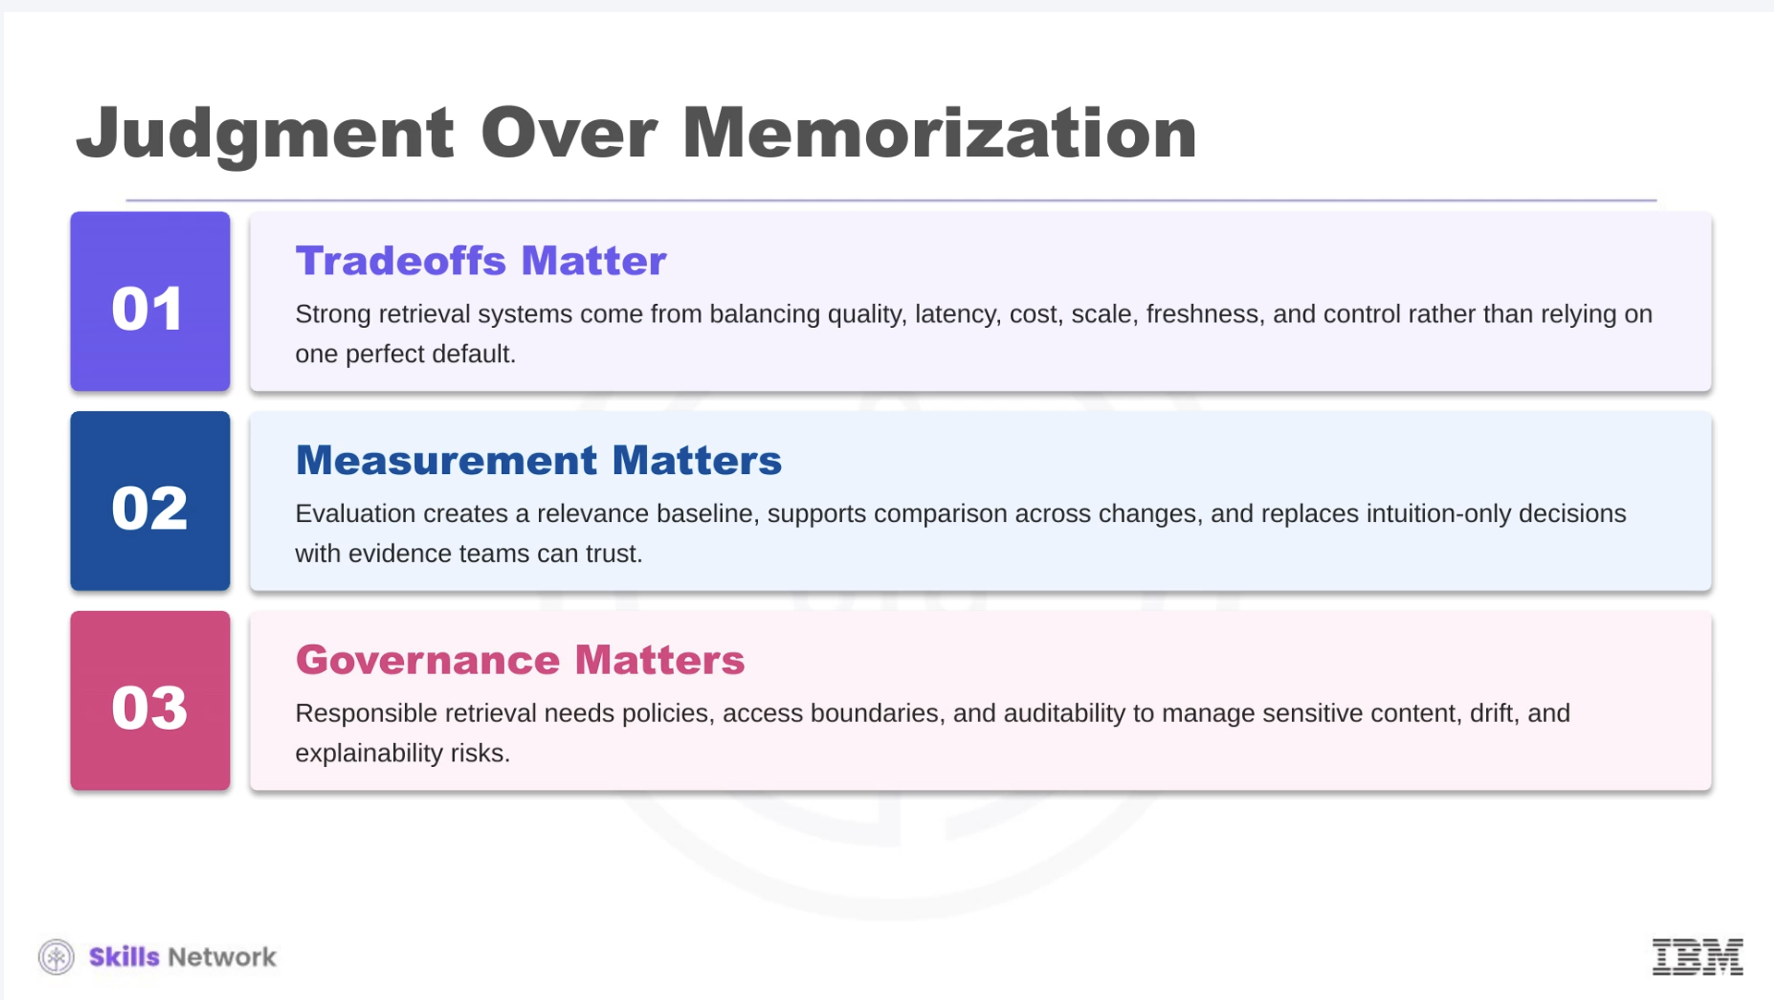
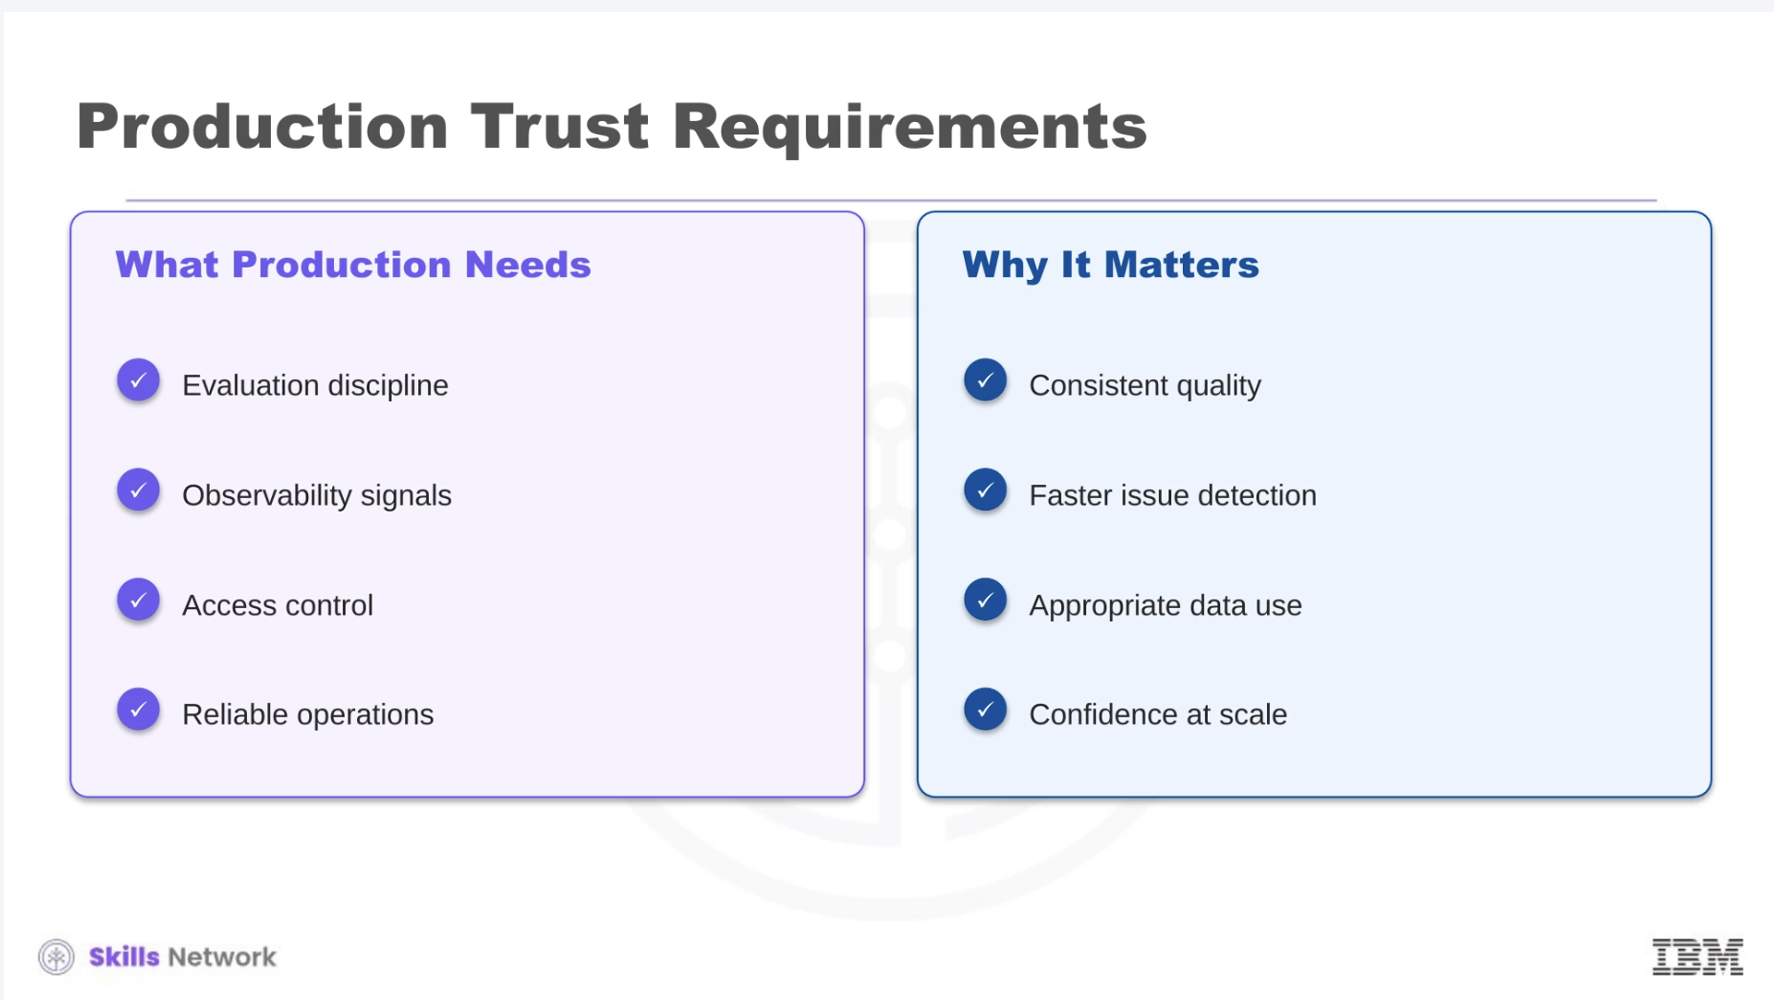
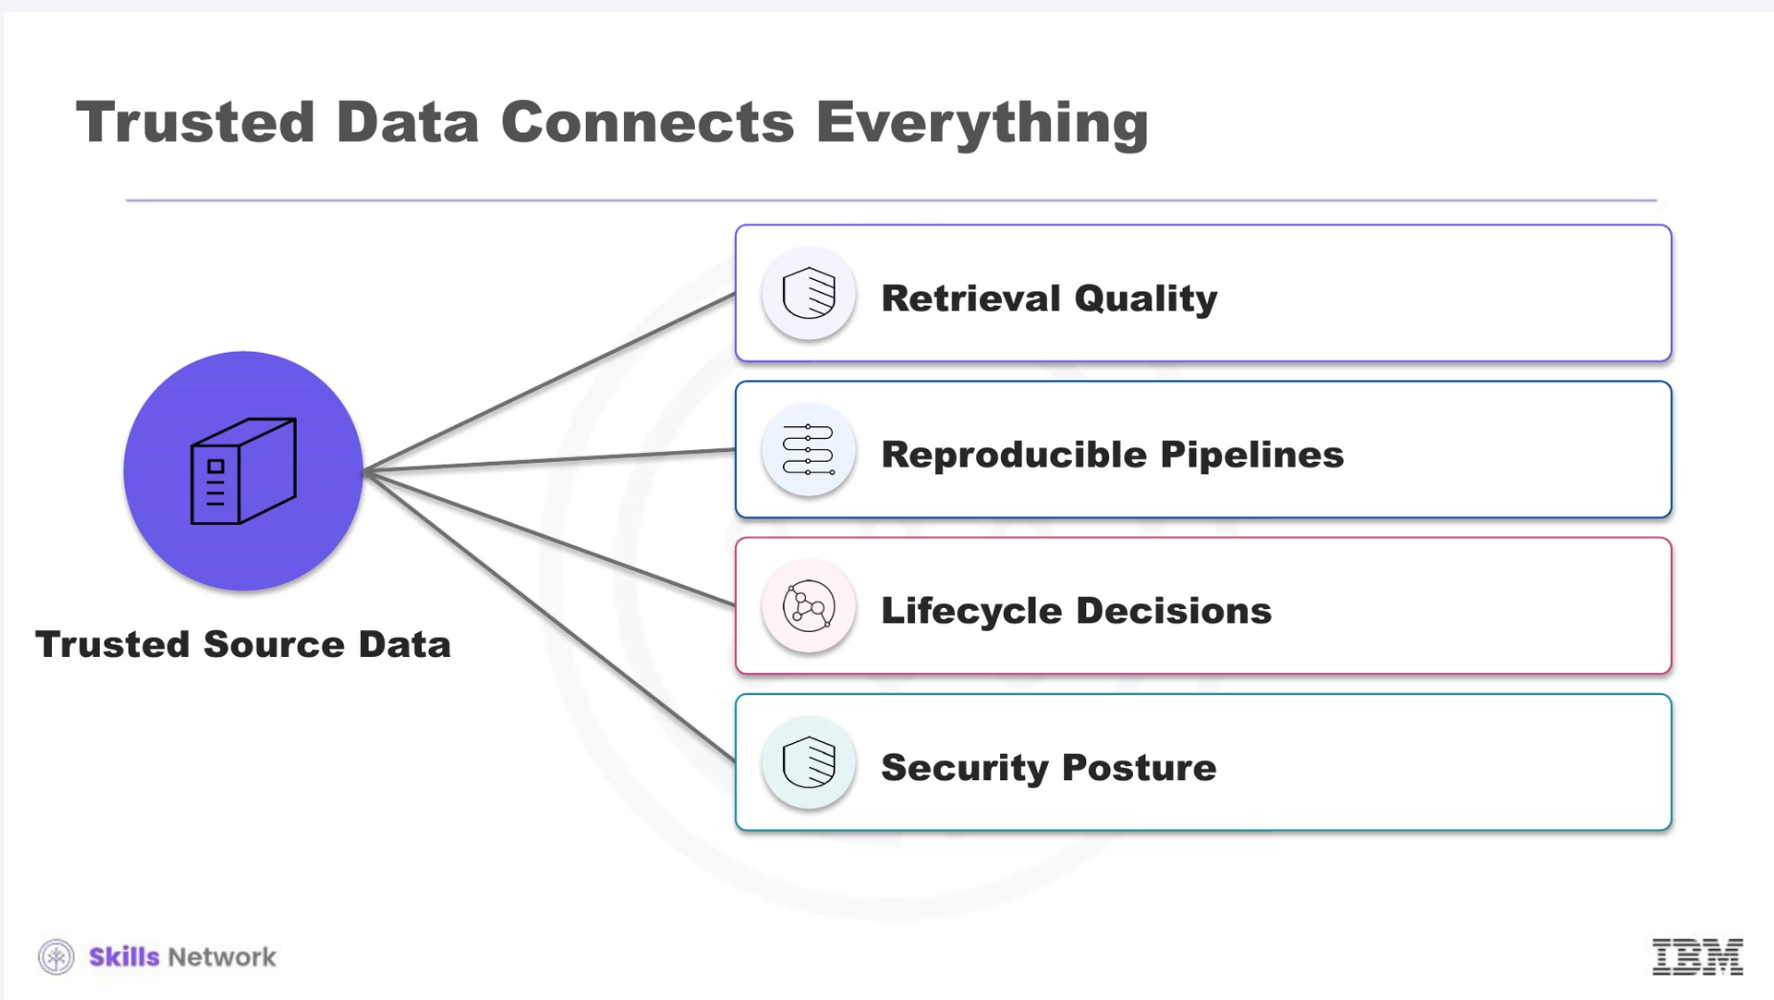
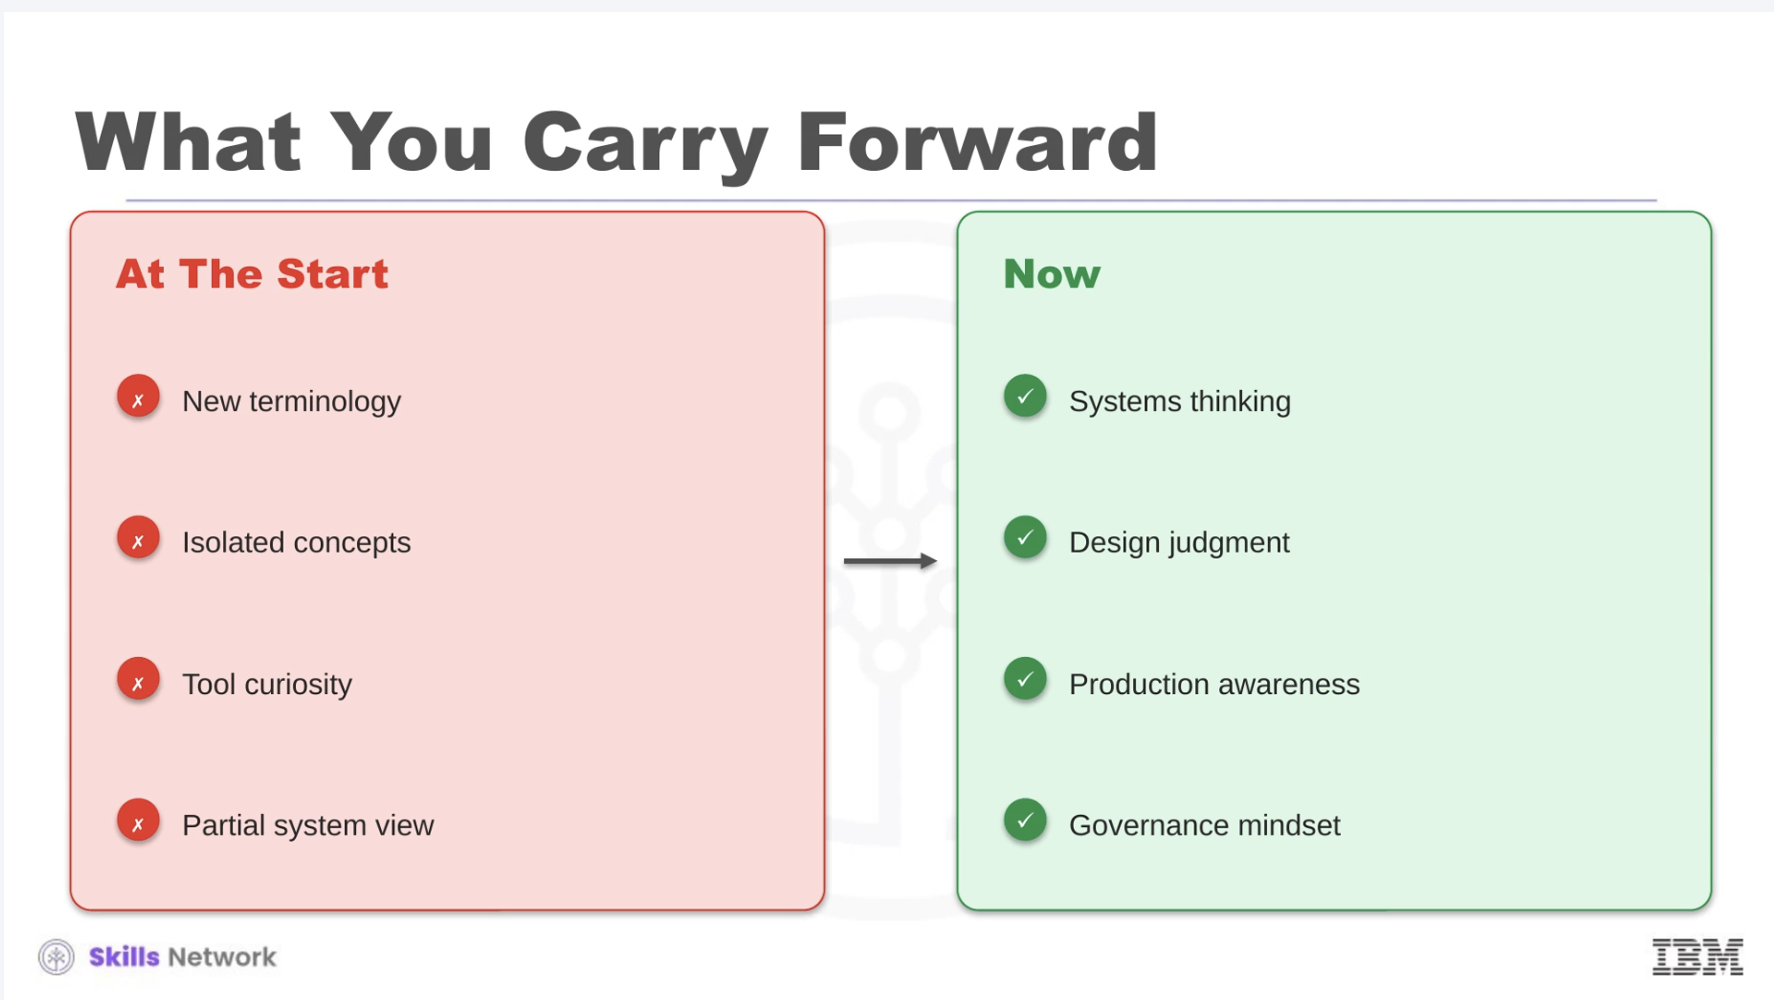


# 🏆 Northstar Search — Final Case Study

Don't treat this as another random case. This is basically:

> 📌 **"You have learned all these retrieval engineering concepts. Now design the production system."**

The case gives 4 major decisions:

1. What retrieval strategy?
2. What ANN index?
3. What metadata/schema?
4. How do updates, deletes, ACL changes and rebuilds work?

---

## 1. First understand Northstar's actual problem

Northstar has:

- 12,400 employees
- 4.8M documents
- 38M chunks
- SharePoint, Google Drive, Confluence, Jira, GitHub
- Current system = **keyword search**
- ACL propagation can take **68 minutes**
- **17 unauthorized chunks** found in 50k-query replay

But the bigger problem is the **query distribution**. They have two fundamentally different types of queries.

### Exact queries

```
ERR_CONN_RESET_1042
JIRA-48291
"Password Rotation Policy"
```

Keyword search is excellent here. For example, error codes:

| Method | MRR |
|---|---|
| Lexical | **0.96** |
| Dense | 0.63 |
| Hybrid | 0.95 |

### Semantic queries

```
"how long do we keep snapshots?"

"why does the deployment keep failing?"

"what is our retention period?"
```

Keyword matching struggles.

| Method | Policy paraphrases — Recall | Troubleshooting — Recall |
|---|---|---|
| Lexical | 0.41 | 0.46 |
| Dense | 0.72 | 0.74 |
| Hybrid | **0.79** | **0.81** |

So the fundamental conclusion is:

> 💡 **Northstar has a mixed-intent workload.**

| | Exact queries | Semantic queries |
|---|---|---|
| Example | `ERR_CONN_RESET_1042`<br>`JIRA-48291` | "how long do we keep snapshots?" |
| Lexical | Excellent (MRR 0.96) | Struggles (recall 0.41–0.46) |
| Dense | Weak (MRR 0.63) | Good (recall 0.72–0.74) |

---

## 🔴 2. Decision 1 — Retrieval strategy

The choices are essentially:

- Lexical
- Dense
- Hybrid
- Split everything

### ❌ Why not lexical?

It handles:

```
IDs
error codes
exact titles
```

beautifully. But it sucks at semantic/paraphrased questions.

### ❌ Why not dense?

Dense does the opposite. Great at semantic meaning. Bad at exact identifiers. For literal queries:

```
Lexical MRR = 0.96
Dense MRR   = 0.63
```

### ✅ HYBRID

**Therefore: Hybrid.**

```
                Query
                  │
          ┌───────┴────────┐
          ↓                ↓
      Lexical           Dense
       Search           Search
          │                │
          └───────┬────────┘
                  ↓
             Fusion/Rerank
                  ↓
               Results
```

Hybrid achieves:

```
MRR       = 0.78
Recall@10 = 0.84
```

**Best overall in the bake-off.**

---

## 🔴 3. Decision 2 — Which ANN index?

Now we're choosing how the **dense retrieval component** works.

The candidates:

| Index | Recall@10 | p95 | Memory | Cost |
|---|---|---|---|---|
| Exact | 0.93 | 2480 ms | 1.8 TB | $71k |
| HNSW 32/96 | 0.90 | 620 ms | 910 GB | $39k |
| HNSW 16/48 | 0.86 | 410 ms | 690 GB | $31k |
| IVF | 0.84 | 540 ms | 520 GB | $24k |
| IVF + PQ | 0.81 | 360 ms | 280 GB | $18k |

Northstar has a:

| Constraint | Value |
|---|---|
| Internal target | 900 ms |
| Hard SLA | 1.5 s |

### ❌ Exact

```
2480 ms ❌
```

**Way too slow.**

### ❌ IVF + PQ

Cheap and fast, but:

```
Recall = 0.81
```

And remember: their whole problem is that **semantic troubleshooting retrieval is already weak**. So sacrificing more recall is bad.

### ✅ HNSW M=32, efSearch=96

```
Recall = 0.90
p95    = 620 ms
```

That's the **sweet spot**.

**✅ Choose HNSW 32 / 96**

The tradeoff is:

> 💡 **More memory and infrastructure cost in exchange for better retrieval quality.**

The instructor explicitly selects this configuration.

---

## 🔴 4. Decision 3 — What goes inside the vector record?

This is where everything we've studied about **metadata** becomes real.

Minimum schema:

```
tenant_id
source_system
source_doc_id
source_version
chunk_id
chunk_hash
source_url
title
owner_team
classification
acl_principal_hashes
created_at
updated_at
ingested_at
embedding_model
embedding_version
```

**Why do we need all this?** Because the vector itself can't tell us:

```
"Where did I come from?"
```

You need:

```
Vector
  ↓
chunk_id
  ↓
source_doc_id
  ↓
source_version
  ↓
SharePoint/Jira/etc.
```

| Need | Fields |
|---|---|
| **Lineage** (where did I come from?) | `chunk_id`<br>`source_doc_id`<br>`source_version` |
| **Security** | `tenant_id`<br>ACL<br>`classification` |
| **Freshness / debugging** | `updated_at`<br>`ingested_at`<br>`embedding_version` |

This is why we've repeatedly said:

> 📌 **The vector database is a derived retrieval structure, not the source of truth.**

---

## 🔴 5. Decision 4 — Incremental updates or rebuilds?

This one is **both**. Not:

```
"incremental OR rebuild"
```

but:

```
incremental + controlled shadow rebuilds
```

### Normal changes

Use **incremental updates**:

```
Source changes
      ↓
CDC / webhook
      ↓
Deterministic upsert
      ↓
Vector index
```

Good for:

- new documents
- updated documents
- ACL changes
- deletes

### Deep representation changes

Use **rebuild**:

```
New embedding model
       ↓
Shadow index
       ↓
Evaluate
       ↓
Validate
       ↓
Switch traffic
```

| | Incremental updates | Shadow rebuild |
|---|---|---|
| Trigger | Normal source changes | New embedding model / deep representation change |
| Flow | CDC/webhook → deterministic upsert → vector index | Shadow index → evaluate → validate → switch traffic |
| Good for | New/updated docs, ACL changes, deletes | Representation changes |

### Why?

Because Northstar already has:

| Metric | Current | Target |
|---|---|---|
| Duplicate chunk IDs | 0.9% | **0** |
| Title/URL mismatch | 2.7% | **0.2%** |
| Update success | 96.8% | **99.9%** |

So simply saying:

```
"We'll refresh more frequently"
```

isn't enough.

> 💡 **They need idempotency + validation + rollback gates.**

---

## 🔴 6. And then comes the security problem

This is the part that connects directly to **Meridian**.

| Metric | Current | Target |
|---|---|---|
| ACL propagation p95 | 68 min | **15 min** |
| Unauthorized chunks | 17 | **0** |

So their retrieval should **NOT** be:

```
Vector search
    ↓
Reranker
    ↓
"Oops, this user can't see this"
```

Instead:

```
User
 ↓
Identity
 ↓
Tenant + ACL resolution
 ↓
PRE-FILTER
 ↓
Vector search
 ↓
Reranker
 ↓
Answer
```

The decision point explicitly recommends:

> 📌 **Mandatory pre-retrieval metadata filters enforced from source-derived ACLs.**

---

## 🔥 7. Final Northstar architecture

Putting the entire case together:

```
                         USER
                           │
                           ▼
                    Authentication
                           │
                           ▼
                 Tenant / ACL Resolution
                           │
                           ▼
                  Server-side Pre-filter
                           │
                ┌──────────┴──────────┐
                ▼                     ▼
           Lexical Search         HNSW Search
                                      │
                                      │
                └──────────┬──────────┘
                           ▼
                      Hybrid Fusion
                           │
                           ▼
                        Reranker
                           │
                           ▼
                       Response
```

And underneath:

```
SharePoint ─┐
Drive ──────┤
Jira ───────┤
Confluence ─┤──→ CDC / Snowflake
GitHub ─────┘          │
                       ▼
               Incremental Pipeline
                       │
                       ▼
                  Vector Store
```

And for major representation changes:

```
Current Index
     │
     │ normal updates
     ▼
Incremental sync

New embedding/model/schema
     │
     ▼
Shadow Index
     │
     ▼
Evaluation
     │
     ▼
Validation
     │
     ▼
Traffic Switch
```

---

## 🧠 8. The final recommendation

The case's final answer is essentially:

| Choice | Because |
|---|---|
| **Hybrid retrieval** | Query intent is mixed |
| **HNSW M=32 / efSearch=96** | Balances recall, latency and cost |
| **Metadata-rich schema** | Security, lineage, freshness and auditing depend on it |
| **Pre-retrieval ACL filtering** | Unauthorized content should never become retrieval candidates |
| **Incremental idempotent sync** | For normal updates/deletes/permissions |
| **Shadow rebuilds** | For embedding/schema/representation changes |
| **One shared index initially** | With strict metadata filtering, rather than exploding into many separate indexes |

> 📌 The case explicitly lands on **Option 1** with this combination.

---

## 🔥 9. And THIS is why this case was saved for last

Look at what it made me use:

```
Course 3
│
├── Hybrid retrieval
├── Dense vs lexical
├── HNSW
├── ANN tradeoffs
├── Metadata schema
├── Source of truth
├── CDC
├── Incremental updates
├── Idempotency
├── Deletes
├── ACL propagation
├── Pre-filtering
├── Tenant isolation
├── Evaluation
├── Golden queries
├── Sliced metrics
├── Freshness
├── Auditability
└── Shadow rebuilds
```

This is basically **the final exam of Course 3**. 😂

And the beautiful part is that I now have enough understanding to actually **defend why each component exists**, rather than just naming technologies.

So yeah... NOW we can officially say:

> 🏆 **COURSE 3 ACTUALLY DONE.**